In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn import metrics

In [2]:
# Import data
df=pd.read_csv("../datasets/Labeled/combined_dataset.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,Socket,Algorithm,Start Time,End Time,Execution Time,Power,Current,Voltage,Memory,CPU Usage,...,Num Files,Size,Avg File Size,CPU Count,Total RAM,Available RAM,System CPU,System Memory,Time Per File,Throughput
1,rpi4,cross-rsdp-128-small,2026-01-15 17:18:19.226618,2026-01-15 17:18:24.688739,5.4621023030000500,3.754,0.048,116.0205,320.04179191589400,99.96151110170730,...,5,310.0,62.0,4,7812.31640625,7118.9453125,0.0,9.2,1.0909483233999900,56.83128950303900
2,rpi5,ML-DSA-87,2026-01-15 17:16:03.047769,2026-01-15 17:16:05.649821,2.6020486489999300,4.451,0.057,116.037,320.02637004852300,99.92126784406150,...,5,310.0,62.0,4,16215.125,15631.9375,0.0,5.3,0.520009268400031,119.22864411775200
3,rpi5,ML-DSA-44,2026-01-15 17:15:55.837435,2026-01-15 17:15:58.435796,2.5983588620000500,4.394,0.058,116.169,320.01661109924300,100.06316055968800,...,5,310.0,62.0,4,16215.125,15631.9375,0.0,5.5,0.5192870786000190,119.39445935598900
4,rpi3,cross-rsdp-128-fast,2026-01-15 17:37:03.121261,2026-01-15 17:38:29.064142,85.94285562800000,3.8999666666666700,0.04933333333333340,116.779,320.0563220977780,99.99667729448930,...,5,310.0,62.0,4,923.20703125,730.96875,0.0,20.7,17.182764662200000,3.608266842901730


In [3]:
df.columns = df.iloc[0]
df = df[1:]
df.head()

,Socket,Algorithm,Start Time,End Time,Execution Time,Power,Current,Voltage,Memory,CPU Usage,...,Num Files,Size,Avg File Size,CPU Count,Total RAM,Available RAM,System CPU,System Memory,Time Per File,Throughput
1,rpi4,cross-rsdp-128-small,2026-01-15 17:18:19.226618,2026-01-15 17:18:24.688739,5.4621023030000500,3.754,0.048,116.0205,320.04179191589400,99.96151110170730,...,5,310.0,62.0,4,7812.31640625,7118.9453125,0.0,9.2,1.0909483233999900,56.83128950303900
2,rpi5,ML-DSA-87,2026-01-15 17:16:03.047769,2026-01-15 17:16:05.649821,2.6020486489999300,4.451,0.057,116.037,320.02637004852300,99.92126784406150,...,5,310.0,62.0,4,16215.125,15631.9375,0.0,5.3,0.520009268400031,119.22864411775200
3,rpi5,ML-DSA-44,2026-01-15 17:15:55.837435,2026-01-15 17:15:58.435796,2.5983588620000500,4.394,0.058,116.169,320.01661109924300,100.06316055968800,...,5,310.0,62.0,4,16215.125,15631.9375,0.0,5.5,0.5192870786000190,119.39445935598900
4,rpi3,cross-rsdp-128-fast,2026-01-15 17:37:03.121261,2026-01-15 17:38:29.064142,85.94285562800000,3.8999666666666700,0.04933333333333340,116.779,320.0563220977780,99.99667729448930,...,5,310.0,62.0,4,923.20703125,730.96875,0.0,20.7,17.182764662200000,3.608266842901730
5,rpi4,SPHINCS+-SHA2-192f-simple,2026-01-15 17:16:42.197956,2026-01-15 17:16:48.841743,6.643768490999950,3.727,0.0465,115.9295,320.1077241897580,99.94327780979950,...,5,310.0,62.0,4,7812.31640625,7118.9453125,0.0,9.2,1.32607025719999,46.75468713921210


In [4]:
# Feature selection
X = df.drop(columns=['Algorithm', 'Start Time', 'End Time', 'Write Bytes', 'Num Files', 'Size', 'Avg File Size', 'CPU Count', 'System CPU'], axis=1)
y = df['Algorithm']

# Ensure consistent data types
string_cols = X.columns[X.columns != 'Socket']
X[string_cols] = X[string_cols].astype(float)

In [5]:
# Split data

object_cols = [col for col in X.columns if X[col].dtype == "object"]
low_cardinality_cols = [col for col in object_cols if X[col].nunique() < 10]

In [6]:
num_X = X.select_dtypes(exclude=['object'])
OH_cols = pd.get_dummies(X[low_cardinality_cols],drop_first=False)
X = pd.concat([num_X, OH_cols], axis=1)

In [7]:
# Using Leave-One-Out Cross-Validation
loo = LeaveOneOut()
y_predict = []
y_true = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Create and fit the model
    rf = RandomForestClassifier()
    rf = rf.fit(X_train, y_train)

    # Predict and store results
    y_predict.append(rf.predict(X_test)[0])
    y_true.append(y_test.iloc[0])

In [8]:
# Accuracy
import numpy as np

print("Accuracy of Random Forest model is ", metrics.accuracy_score(y_true, y_predict))
print("Precision (weighted) is ", metrics.precision_score(y_true, y_predict, average="weighted", zero_division=np.NaN))
print("Recall (weighted) is ", metrics.recall_score(y_true, y_predict, average="weighted", zero_division=np.NaN))
print("F1 Score (weighted) is ", metrics.f1_score(y_true, y_predict, average="weighted"))

Accuracy of Random Forest model is  0.050505050505050504
Precision (weighted) is  0.035
Recall (weighted) is  0.050505050505050504
F1 Score (weighted) is  0.03896103896103896


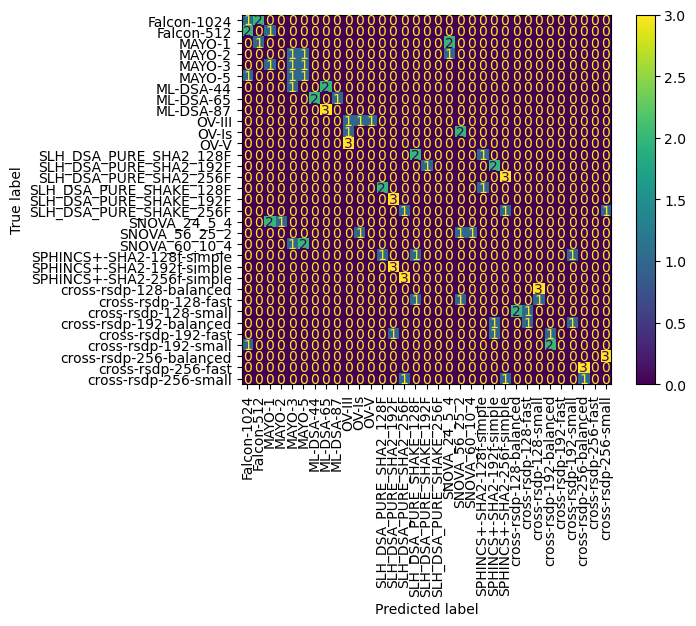

In [9]:
# Confusion matrix
# labels = ["cipher1", "cipher2", ...]
cm = metrics.confusion_matrix(y_true, y_predict)
display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
display.plot(xticks_rotation='vertical')

In [13]:
# ROC curve
from sklearn.preprocessing import label_binarize

classes = rf.classes_
y_true_bin = label_binarize(y_true, classes=classes)
n_classes = y_true_bin.shape[1]

# Collect probability scores across all LOO folds
y_scores = np.zeros((len(y_true), n_classes))
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train = y.iloc[train_index]

    rf.fit(X_train, y_train)
    y_scores[test_index] = rf.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = metrics.roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])

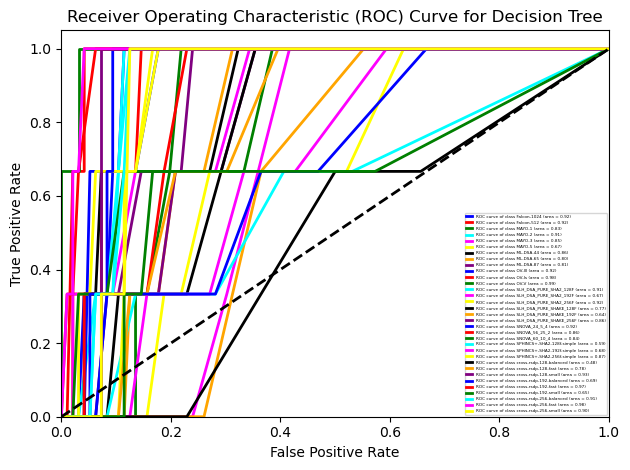

In [14]:
# Plot the ROC curve for each class
import matplotlib.pyplot as plt
from itertools import cycle

plt.figure()
classes = rf.classes_
colors = ['blue', 'red', 'green', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple']
color_cycle = cycle(colors)
for i, cur_class in zip(range(n_classes), classes):
    color = next(color_cycle)
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(cur_class, roc_auc[i]))

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve for Decision Tree")
plt.legend(
    fontsize='3',
    markerscale=0.7,
    handlelength=1.5,
    labelspacing=0.5,
    borderpad=0.3,
    loc="lower right"
)
plt.tight_layout()
plt.show()

In [12]:
from joblib import dump

dump(rf, 'rf.joblib')

['rf.joblib']